Sedang mengunduh data Bitcoin...


/tmp/ipython-input-846394731.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download('BTC-USD', period='5y', interval='1d')
[*********************100%***********************]  1 of 1 completed


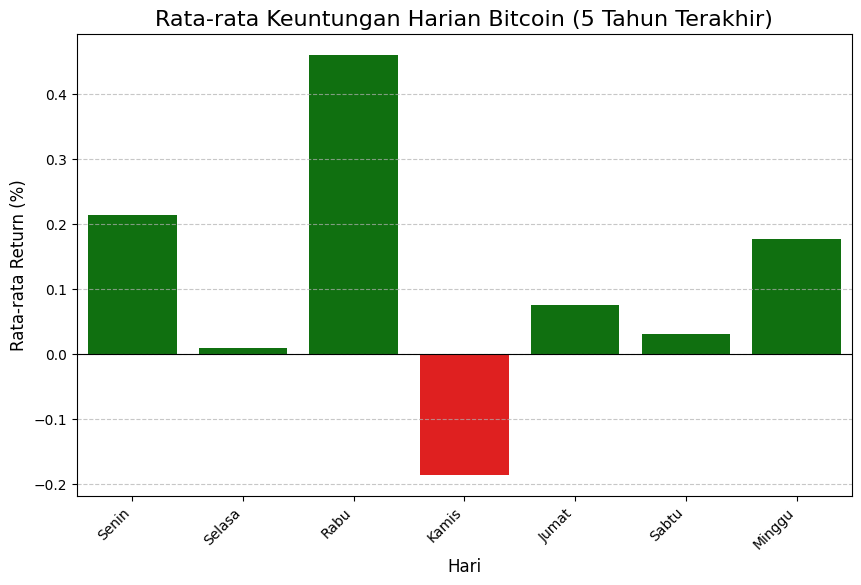


Rata-rata Return per Hari (%):
Day
Senin     0.213243
Selasa    0.009529
Rabu      0.460469
Kamis    -0.185946
Jumat     0.075744
Sabtu     0.030089
Minggu    0.176989
Name: Return, dtype: float64


In [3]:
# 1. Install library yang dibutuhkan (jika di Colab)
!pip install yfinance matplotlib seaborn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Ambil Data Bitcoin (BTC-USD) 5 Tahun Terakhir
print("Sedang mengunduh data Bitcoin...")
btc = yf.download('BTC-USD', period='5y', interval='1d')

# 3. Bersihkan Data (Hitung Daily Return / Keuntungan Harian dalam %)
# Rumus: (Harga Hari Ini - Harga Kemarin) / Harga Kemarin
btc['Return'] = btc['Close'].pct_change() * 100
btc['Day'] = btc.index.day_name()

# 4. Hitung Rata-rata Return per Hari
# Mengurutkan hari dari Senin sampai Minggu (menggunakan nama hari dalam bahasa Inggris agar cocok dengan btc.index.day_name())
days_order_english = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = btc.groupby('Day')['Return'].mean().reindex(days_order_english)

# Untuk tampilan grafik, kita bisa menggunakan mapping ke nama hari dalam bahasa Indonesia
day_name_mapping = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}

# Buat DataFrame dari daily_avg untuk penggunaan seaborn yang lebih baik
daily_avg_df = daily_avg.reset_index()
daily_avg_df.columns = ['Day', 'Return']
daily_avg_df['Profit'] = daily_avg_df['Return'] > 0

# 5. Visualisasi Data (Membuat Grafik)
plt.figure(figsize=(10, 6))

# Define custom palette for positive (green) and negative (red) returns
custom_palette = {True: 'green', False: 'red'}

sns.barplot(x='Day', y='Return', data=daily_avg_df, hue='Profit', palette=custom_palette, legend=False)

plt.title('Rata-rata Keuntungan Harian Bitcoin (5 Tahun Terakhir)', fontsize=16)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Rata-rata Return (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8) # Garis nol
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mengatur label sumbu x ke nama hari dalam bahasa Indonesia
plt.xticks(ticks=range(len(daily_avg_df['Day'])), labels=[day_name_mapping[day] for day in daily_avg_df['Day']], rotation=45, ha='right')

# Tampilkan Grafik
plt.show()

# Tampilkan Angka Pasti
print("\nRata-rata Return per Hari (%):")
print(daily_avg.rename(index=day_name_mapping))
